In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
'/content/drive/MyDrive/'

'/content/drive/MyDrive/'

In [ ]:
from diffusers import StableDiffusionPipeline
import torch
from tqdm import tqdm
import os
from google.colab import drive


device = "cuda" if torch.cuda.is_available() else "cpu"


pipeline = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
pipeline = pipeline.to(device)

def generate_images(prompt_file, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    with open(prompt_file, 'r') as f:
        prompts = [line.strip() for line in f if line.strip()]

    print(f"Generating {len(prompts)} images in '{output_folder}'...")

    for idx, prompt in enumerate(tqdm(prompts)):
        image_filename = f"sample_{idx+1:04d}.png"
        image_path = os.path.join(output_folder, image_filename)

        if os.path.exists(image_path):
            continue

        try:
            with torch.autocast(device):
                image = pipeline(prompt).images[0]

            image.save(image_path)

            prompt_filename = f"sample_{idx+1:04d}.txt"
            prompt_path = os.path.join(output_folder, prompt_filename)
            with open(prompt_path, 'w') as f:
                f.write(prompt)

        except Exception as e:
            print(f"❌ Error on index {idx}: {e}")
            torch.cuda.empty_cache()

    print(f"✅ Generation complete! Saved in '{output_folder}'")

train_prompt_file = "/content/train_prompts.txt"
test_prompt_file = "/content/test_prompts.txt"

train_output_folder = "/content/drive/MyDrive/stable_diffusion_outputs/train"
test_output_folder = "/content/drive/MyDrive/stable_diffusion_outputs/test"

generate_images(train_prompt_file, train_output_folder)
generate_images(test_prompt_file, test_output_folder)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

100%|█████████▉| 399/400 [45:05<00:08,  8.34s/it]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 400/400 [45:13<00:00,  6.78s/it]

✅ Generation complete! Saved in '/content/drive/MyDrive/stable_diffusion_outputs/test'


Pre-processing

In [ ]:
import os
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
import shutil

resize_to = (128, 128)

resize_transform = transforms.Compose([
    transforms.Resize(resize_to),
    transforms.CenterCrop(resize_to),
])

base_input_folder = "/content/drive/MyDrive/stable_diffusion_outputs"
base_output_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized"

splits = ["train", "test"]

for split in splits:
    original_folder = os.path.join(base_input_folder, split)
    resized_folder = os.path.join(base_output_folder, split)
    os.makedirs(resized_folder, exist_ok=True)

    image_files = sorted([f for f in os.listdir(original_folder) if f.endswith(".png")])

    for img_name in tqdm(image_files, desc=f"Resizing {split} images"):
        src_img_path = os.path.join(original_folder, img_name)
        dst_img_path = os.path.join(resized_folder, img_name)

        try:
            with Image.open(src_img_path) as img:
                img = img.convert("RGB")
                img = resize_transform(img)
                img.save(dst_img_path)
        except Exception as e:
            print(f"❌ Failed to resize {img_name}: {e}")
            continue

        prompt_name = img_name.replace(".png", ".txt")
        src_prompt_path = os.path.join(original_folder, prompt_name)
        dst_prompt_path = os.path.join(resized_folder, prompt_name)

        if os.path.exists(src_prompt_path):
            shutil.copy(src_prompt_path, dst_prompt_path)

print("✅ All train/test images resized and prompts copied!")

Resizing test images: 100%|██████████| 400/400 [00:24<00:00, 16.30it/s]

✅ All train/test images resized and prompts copied!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from torchvision.utils import save_image
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Encoder ===
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(512 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(512 * 8 * 8, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

# === Decoder ===
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 512, 8, 8)
        return self.deconv(h)

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

from PIL import Image

class ImagePromptDataset(Dataset):
    def __init__(self, image_folder):
        self.image_paths = sorted([os.path.join(image_folder, f)
                                   for f in os.listdir(image_folder) if f.endswith('.png')])
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = self.transform(img)
        return img


def train_vae_gan(dataloader, encoder, decoder, discriminator,
                  vae_optimizer, dis_optimizer, epochs=10):
    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        discriminator.train()

        total_vae_loss = 0
        for batch in dataloader:
            batch = batch.to(device)

            mu, logvar = encoder(batch)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            recon_loss = F.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(batch)
            vae_loss = recon_loss + kl_loss

            real_labels = torch.ones(len(batch), 1).to(device)
            fake_labels = torch.zeros(len(batch), 1).to(device)

            dis_optimizer.zero_grad()
            real_loss = F.binary_cross_entropy(discriminator(torch.randn_like(z)), real_labels)
            fake_loss = F.binary_cross_entropy(discriminator(z.detach()), fake_labels)
            dis_loss = real_loss + fake_loss
            dis_loss.backward()
            dis_optimizer.step()

            vae_optimizer.zero_grad()
            gan_loss = F.binary_cross_entropy(discriminator(z), real_labels)
            total_loss = vae_loss + gan_loss * 0.1
            total_loss.backward()
            vae_optimizer.step()

            total_vae_loss += total_loss.item()

        print(f"[{epoch+1}/{epochs}] 🔧 VAE-GAN Loss: {total_vae_loss:.4f}")


train_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized/train"


latent_dim = 128
batch_size = 16

dataset = ImagePromptDataset(train_folder)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

encoder = Encoder(latent_dim).to(device)
decoder = Decoder(latent_dim).to(device)
discriminator = Discriminator(latent_dim).to(device)

vae_optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)
dis_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

train_vae_gan(dataloader, encoder, decoder, discriminator, vae_optimizer, dis_optimizer, epochs=10)

encoder.eval()
all_latents = []

with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)
        mu, logvar = encoder(batch)
        z = reparameterize(mu, logvar)
        all_latents.append(z.cpu())

import numpy as np
all_latents = torch.cat(all_latents, dim=0).numpy()
np.save("/content/drive/MyDrive/vae_latents.npy", all_latents)
print("✅ Latents saved to Google Drive!")

Using device: cuda
[1/10] 🔧 VAE-GAN Loss: 773.3131
[2/10] 🔧 VAE-GAN Loss: 67.8789
[3/10] 🔧 VAE-GAN Loss: 39.5545
[4/10] 🔧 VAE-GAN Loss: 32.1701
[5/10] 🔧 VAE-GAN Loss: 27.9426
[6/10] 🔧 VAE-GAN Loss: 28.4065
[7/10] 🔧 VAE-GAN Loss: 26.4668
[8/10] 🔧 VAE-GAN Loss: 25.2970
[9/10] 🔧 VAE-GAN Loss: 25.8517
[10/10] 🔧 VAE-GAN Loss: 33.2235
✅ Latents saved to Google Drive!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from sklearn.model_selection import train_test_split
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Encoder ===
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(512 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(512 * 8 * 8, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

# === Decoder ===
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 512, 8, 8)
        return self.deconv(h)

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

class ImagePromptDataset(Dataset):
    def __init__(self, image_folder):
        self.image_paths = sorted([os.path.join(image_folder, f)
                                   for f in os.listdir(image_folder) if f.endswith('.png')])
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = self.transform(img)
        return img

def compute_discriminator_accuracy(discriminator, real_z, fake_z):
    with torch.no_grad():
        real_preds = discriminator(real_z)
        fake_preds = discriminator(fake_z)
        real_acc = (real_preds > 0.5).float().mean()
        fake_acc = (fake_preds < 0.5).float().mean()
        return ((real_acc + fake_acc) / 2).item()

def validate_vae_gan(val_loader, encoder, decoder, discriminator):
    encoder.eval()
    decoder.eval()
    discriminator.eval()

    total_val_loss = 0
    total_acc = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            mu, logvar = encoder(batch)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            recon_loss = F.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(batch)
            vae_loss = recon_loss + kl_loss

            # GAN accuracy
            real_z = torch.randn_like(z)
            acc = compute_discriminator_accuracy(discriminator, real_z, z)

            total_val_loss += vae_loss.item()
            total_acc += acc

    return total_val_loss / len(val_loader), total_acc / len(val_loader)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def train_vae_gan(train_loader, val_loader, encoder, decoder, discriminator,
                  vae_optimizer, dis_optimizer, epochs=10):
    history = {
        'vae_loss': [], 'recon_loss': [], 'kl_loss': [], 'mse_loss': [],  # ✅ MSE added
        'dis_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
        'all_real_scores': [], 'all_fake_scores': [], 'all_labels': []
    }

    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        discriminator.train()

        total_vae_loss = 0
        total_recon_loss = 0
        total_mse_loss = 0  # ✅ track MSE
        total_kl_loss = 0
        total_dis_loss = 0
        total_acc = 0

        real_scores_epoch, fake_scores_epoch, labels_epoch = [], [], []

        for batch in train_loader:
            batch = batch.to(device)

            mu, logvar = encoder(batch)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            mse_loss = F.mse_loss(recon, batch)  # ✅ separate MSE
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(batch)
            vae_loss = mse_loss + kl_loss

            real_labels = torch.ones(len(batch), 1).to(device)
            fake_labels = torch.zeros(len(batch), 1).to(device)

            dis_optimizer.zero_grad()
            real_z = torch.randn_like(z)
            dis_real = discriminator(real_z)
            dis_fake = discriminator(z.detach())
            dis_real_loss = F.binary_cross_entropy(dis_real, real_labels)
            dis_fake_loss = F.binary_cross_entropy(dis_fake, fake_labels)
            dis_loss = dis_real_loss + dis_fake_loss
            dis_loss.backward()
            dis_optimizer.step()

            vae_optimizer.zero_grad()
            gan_loss = F.binary_cross_entropy(discriminator(z), real_labels)
            total_loss = vae_loss + 0.1 * gan_loss
            total_loss.backward()
            vae_optimizer.step()

            acc = compute_discriminator_accuracy(discriminator, real_z, z)

            real_scores_epoch.extend(dis_real.detach().cpu().numpy().flatten())
            fake_scores_epoch.extend(dis_fake.detach().cpu().numpy().flatten())
            labels_epoch.extend([1] * len(dis_real) + [0] * len(dis_fake))

            total_vae_loss += vae_loss.item()
            total_recon_loss += (mse_loss.item() + kl_loss.item())  # or just mse if preferred
            total_mse_loss += mse_loss.item()  # ✅ update
            total_kl_loss += kl_loss.item()
            total_dis_loss += dis_loss.item()
            total_acc += acc

        val_loss, val_acc = validate_vae_gan(val_loader, encoder, decoder, discriminator)

        history['vae_loss'].append(total_vae_loss / len(train_loader))
        history['recon_loss'].append(total_recon_loss / len(train_loader))
        history['kl_loss'].append(total_kl_loss / len(train_loader))
        history['mse_loss'].append(total_mse_loss / len(train_loader))  # ✅ logged
        history['dis_loss'].append(total_dis_loss / len(train_loader))
        history['train_acc'].append(total_acc / len(train_loader))
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['all_real_scores'].extend(real_scores_epoch)
        history['all_fake_scores'].extend(fake_scores_epoch)
        history['all_labels'].extend(labels_epoch)

        print(f"[{epoch+1}/{epochs}] 🔧 VAE: {total_vae_loss:.2f} | MSE: {total_mse_loss:.2f} | KL: {total_kl_loss:.2f} | "
              f"D: {total_dis_loss:.2f} | Acc: {total_acc/len(train_loader):.3f} | "
              f"Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.3f}")

    return history



train_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized/train"
test_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized/test"


dataset = ImagePromptDataset(train_folder)
train_set, val_set = train_test_split(dataset, test_size=0.1, shuffle=True)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=2)

latent_dim = 128
encoder = Encoder(latent_dim).to(device)
decoder = Decoder(latent_dim).to(device)
discriminator = Discriminator(latent_dim).to(device)

vae_optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)
dis_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

history = train_vae_gan(train_loader, val_loader, encoder, decoder, discriminator, vae_optimizer, dis_optimizer, epochs=100)

Using device: cuda
[1/100] 🔧 VAE: 792.69 | MSE: 6.24 | KL: 786.45 | D: 125.07 | Acc: 0.501 | Val Loss: 1.78 | Val Acc: 0.503
[2/100] 🔧 VAE: 91.32 | MSE: 6.21 | KL: 85.11 | D: 124.84 | Acc: 0.519 | Val Loss: 0.82 | Val Acc: 0.525
[3/100] 🔧 VAE: 54.93 | MSE: 6.21 | KL: 48.72 | D: 125.09 | Acc: 0.508 | Val Loss: 0.63 | Val Acc: 0.537
[4/100] 🔧 VAE: 40.98 | MSE: 6.20 | KL: 34.77 | D: 125.01 | Acc: 0.512 | Val Loss: 0.48 | Val Acc: 0.487
[5/100] 🔧 VAE: 35.43 | MSE: 6.20 | KL: 29.23 | D: 125.11 | Acc: 0.514 | Val Loss: 0.43 | Val Acc: 0.531
[6/100] 🔧 VAE: 31.99 | MSE: 6.19 | KL: 25.80 | D: 125.12 | Acc: 0.504 | Val Loss: 0.50 | Val Acc: 0.512
[7/100] 🔧 VAE: 28.64 | MSE: 6.20 | KL: 22.44 | D: 124.72 | Acc: 0.525 | Val Loss: 0.32 | Val Acc: 0.519
[8/100] 🔧 VAE: 25.95 | MSE: 6.20 | KL: 19.76 | D: 125.41 | Acc: 0.494 | Val Loss: 0.35 | Val Acc: 0.562
[9/100] 🔧 VAE: 23.02 | MSE: 6.20 | KL: 16.82 | D: 125.11 | Acc: 0.498 | Val Loss: 0.24 | Val Acc: 0.478
[10/100] 🔧 VAE: 21.80 | MSE: 6.20 | KL: 15.

Plot saved to: training_plot.png


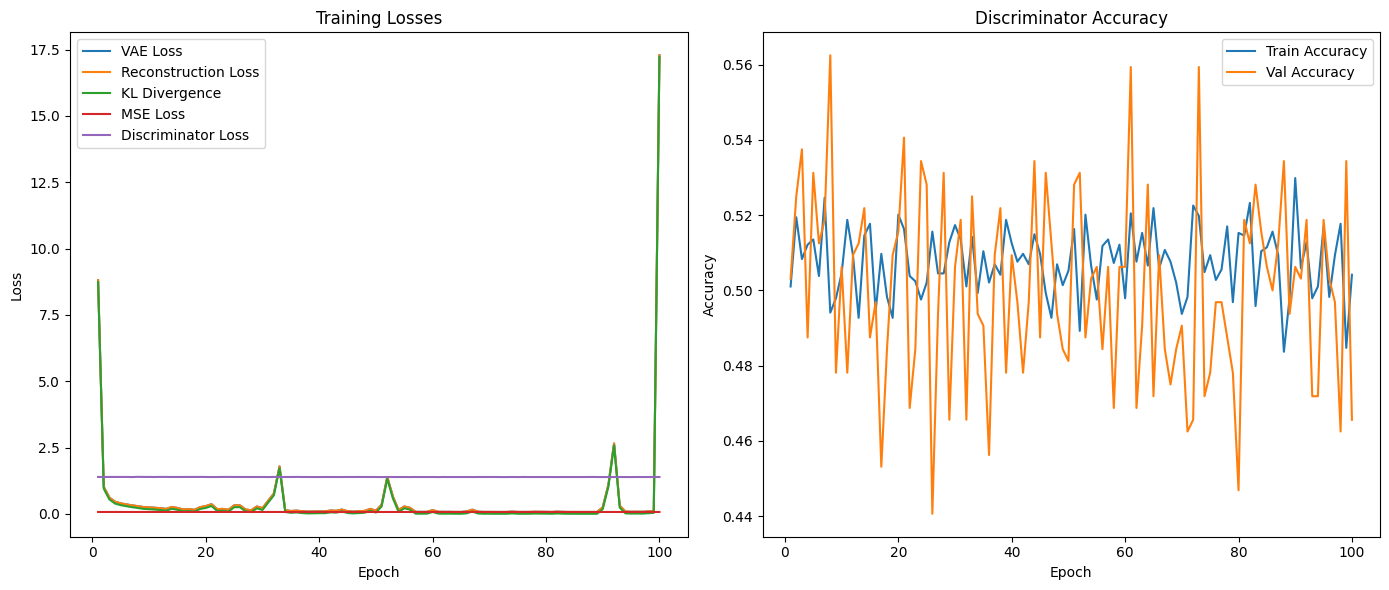

In [ ]:
def plot_and_save_training_history(history, filename='training_plot.png'):
    epochs = range(1, len(history['vae_loss']) + 1)
    plt.figure(figsize=(14, 6))

    # Plotting losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['vae_loss'], label="VAE Loss")
    plt.plot(epochs, history['recon_loss'], label="Reconstruction Loss")
    plt.plot(epochs, history['kl_loss'], label="KL Divergence")
    plt.plot(epochs, history['mse_loss'], label="MSE Loss")  # ✅ Added MSE line
    plt.plot(epochs, history['dis_loss'], label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Losses")
    plt.legend()

    # Plotting accuracies
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label="Train Accuracy")
    plt.plot(epochs, history['val_acc'], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Discriminator Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig(filename)
    print(f"Plot saved to: {filename}")

plot_and_save_training_history(history)

ROC curve saved as: roc_curve.png


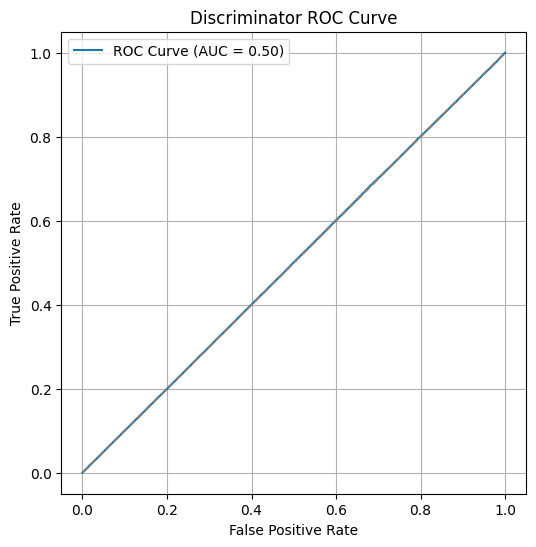

In [ ]:
def plot_roc_curve(history, filename='roc_curve.png'):
    from sklearn.metrics import roc_curve, auc

    y_true = history['all_labels']
    y_scores = history['all_real_scores'] + history['all_fake_scores']

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Discriminator ROC Curve")
    plt.legend()
    plt.grid(True)

    plt.savefig(filename)  # Save to file
    print(f"ROC curve saved as: {filename}")

    plt.show()

# Call the function with your history
plot_roc_curve(history)


In [ ]:
import torch
import numpy as np
import os
from tqdm import tqdm
from torchvision import transforms
from PIL import Image

def extract_and_save_latent_vectors(model, image_folder, save_path):

    model.eval()

    latent_vectors = []

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    image_paths = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.png')])

    with torch.no_grad():
        for img_path in tqdm(image_paths, desc="Extracting latent vectors"):
            img = Image.open(img_path).convert('RGB')
            img = transform(img).unsqueeze(0).to(device)

            mu, logvar = model(img)
            z = reparameterize(mu, logvar)

            latent_vectors.append(z.cpu().numpy())

    latent_vectors = np.concatenate(latent_vectors, axis=0)
    np.save(save_path, latent_vectors)

    print(f"Latent vectors saved to: {save_path}")

test_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized/test"
save_path = "/content/drive/MyDrive/latent_vectors.npy"

extract_and_save_latent_vectors(encoder, test_folder, save_path)

Extracting latent vectors: 100%|██████████| 400/400 [00:10<00:00, 36.47it/s] 


Latent vectors saved to: /content/drive/MyDrive/latent_vectors.npy


Evaluation

In [ ]:
import torch
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np

def compute_psnr(original, reconstructed):
    original = original.detach().cpu().numpy().transpose(0, 2, 3, 1) * 255
    reconstructed = reconstructed.detach().cpu().numpy().transpose(0, 2, 3, 1) * 255
    return psnr(original, reconstructed, data_range=255)

for batch_idx, batch in enumerate(train_loader):
    batch = batch.to(device)

    mu, logvar = encoder(batch)
    z = reparameterize(mu, logvar)
    reconstructed = decoder(z)

    psnr_value = compute_psnr(batch, reconstructed)

    print(f"Batch {batch_idx}: PSNR: {psnr_value:.4f}")

Batch 0: PSNR: 12.2261
Batch 1: PSNR: 11.7710
Batch 2: PSNR: 11.8262
Batch 3: PSNR: 11.5285
Batch 4: PSNR: 11.5449
Batch 5: PSNR: 11.6149
Batch 6: PSNR: 12.0019
Batch 7: PSNR: 11.3807
Batch 8: PSNR: 11.8940
Batch 9: PSNR: 11.9824
Batch 10: PSNR: 11.3915
Batch 11: PSNR: 11.9564
Batch 12: PSNR: 11.6636
Batch 13: PSNR: 12.2086
Batch 14: PSNR: 12.0326
Batch 15: PSNR: 11.7932
Batch 16: PSNR: 11.7977
Batch 17: PSNR: 12.1415
Batch 18: PSNR: 11.1354
Batch 19: PSNR: 11.8081
Batch 20: PSNR: 11.7086
Batch 21: PSNR: 11.4104
Batch 22: PSNR: 11.6153
Batch 23: PSNR: 11.9212
Batch 24: PSNR: 11.7022
Batch 25: PSNR: 11.6730
Batch 26: PSNR: 10.9615
Batch 27: PSNR: 11.4263
Batch 28: PSNR: 11.1813
Batch 29: PSNR: 11.9274
Batch 30: PSNR: 11.1181
Batch 31: PSNR: 11.9407
Batch 32: PSNR: 11.7227
Batch 33: PSNR: 11.3666
Batch 34: PSNR: 11.5433
Batch 35: PSNR: 11.3050
Batch 36: PSNR: 11.9017
Batch 37: PSNR: 11.1435
Batch 38: PSNR: 11.1979
Batch 39: PSNR: 12.0692
Batch 40: PSNR: 11.8974
Batch 41: PSNR: 11.4703
Ba

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

latent_vectors = np.load("/content/drive/MyDrive/latent_vectors.npy")

kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(latent_vectors)

silhouette = silhouette_score(latent_vectors, cluster_labels)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.0029


Augmentation Trial

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from sklearn.model_selection import train_test_split
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Encoder ===
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(512 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(512 * 8 * 8, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

# === Decoder ===
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 512, 8, 8)
        return self.deconv(h)

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

class ImagePromptDataset(Dataset):
    def __init__(self, image_folders):
        self.image_paths = []
        for folder in image_folders:
            self.image_paths.extend([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.png')])

        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img = self.transform(img)
        return img

def compute_discriminator_accuracy(discriminator, real_z, fake_z):
    with torch.no_grad():
        real_preds = discriminator(real_z)
        fake_preds = discriminator(fake_z)
        real_acc = (real_preds > 0.5).float().mean()
        fake_acc = (fake_preds < 0.5).float().mean()
        return ((real_acc + fake_acc) / 2).item()

def validate_vae_gan(val_loader, encoder, decoder, discriminator):
    encoder.eval()
    decoder.eval()
    discriminator.eval()

    total_val_loss = 0
    total_acc = 0
    total_mse = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            mu, logvar = encoder(batch)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            recon_loss = F.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(batch)
            vae_loss = recon_loss + kl_loss

            real_z = torch.randn_like(z)
            acc = compute_discriminator_accuracy(discriminator, real_z, z)

            total_val_loss += vae_loss.item()
            total_mse += recon_loss.item()
            total_acc += acc

    return total_val_loss / len(val_loader), total_acc / len(val_loader), total_mse / len(val_loader)

def train_vae_gan(train_loader, val_loader, encoder, decoder, discriminator,
                  vae_optimizer, dis_optimizer, epochs=10):
    history = {
        'vae_loss': [], 'recon_loss': [], 'kl_loss': [],
        'dis_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
        'train_mse': [], 'val_mse': [],
        'all_real_scores': [], 'all_fake_scores': [], 'all_labels': []
    }

    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        discriminator.train()

        total_vae_loss = 0
        total_recon_loss = 0
        total_kl_loss = 0
        total_dis_loss = 0
        total_acc = 0
        total_mse = 0

        real_scores_epoch, fake_scores_epoch, labels_epoch = [], [], []

        for batch in train_loader:
            batch = batch.to(device)

            mu, logvar = encoder(batch)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            recon_loss = F.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(batch)
            vae_loss = recon_loss + kl_loss

            real_labels = torch.ones(len(batch), 1).to(device)
            fake_labels = torch.zeros(len(batch), 1).to(device)

            dis_optimizer.zero_grad()
            real_z = torch.randn_like(z)
            dis_real = discriminator(real_z)
            dis_fake = discriminator(z.detach())
            dis_real_loss = F.binary_cross_entropy(dis_real, real_labels)
            dis_fake_loss = F.binary_cross_entropy(dis_fake, fake_labels)
            dis_loss = dis_real_loss + dis_fake_loss
            dis_loss.backward()
            dis_optimizer.step()

            vae_optimizer.zero_grad()
            gan_loss = F.binary_cross_entropy(discriminator(z), real_labels)
            total_loss = vae_loss + 0.1 * gan_loss
            total_loss.backward()
            vae_optimizer.step()

            acc = compute_discriminator_accuracy(discriminator, real_z, z)

            real_scores_epoch.extend(dis_real.detach().cpu().numpy().flatten())
            fake_scores_epoch.extend(dis_fake.detach().cpu().numpy().flatten())
            labels_epoch.extend([1] * len(dis_real) + [0] * len(dis_fake))

            total_vae_loss += vae_loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()
            total_dis_loss += dis_loss.item()
            total_acc += acc
            total_mse += recon_loss.item()

        val_loss, val_acc, val_mse = validate_vae_gan(val_loader, encoder, decoder, discriminator)

        history['vae_loss'].append(total_vae_loss / len(train_loader))
        history['recon_loss'].append(total_recon_loss / len(train_loader))
        history['kl_loss'].append(total_kl_loss / len(train_loader))
        history['dis_loss'].append(total_dis_loss / len(train_loader))
        history['train_acc'].append(total_acc / len(train_loader))
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['train_mse'].append(total_mse / len(train_loader))
        history['val_mse'].append(val_mse)
        history['all_real_scores'].extend(real_scores_epoch)
        history['all_fake_scores'].extend(fake_scores_epoch)
        history['all_labels'].extend(labels_epoch)

        print(f"[{epoch+1}/{epochs}] 🔧 VAE Loss: {total_vae_loss:.2f} | Recon: {total_recon_loss:.2f} | KL: {total_kl_loss:.2f} | "
              f"Dis Loss: {total_dis_loss:.2f} | Acc: {total_acc/len(train_loader):.3f} | "
              f"Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.3f} | Train MSE: {total_mse / len(train_loader):.4f} | Val MSE: {val_mse:.4f}")

    return history

# Directories
train_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized/train"
augmented_folder = "/content/drive/MyDrive/stable_diffusion_outputs_augmented/train"
test_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized/test"

# Combine original and augmented data
dataset = ImagePromptDataset([train_folder, augmented_folder])
train_set, val_set = train_test_split(dataset, test_size=0.1, shuffle=True)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=2)

latent_dim = 128
encoder = Encoder(latent_dim).to(device)
decoder = Decoder(latent_dim).to(device)
discriminator = Discriminator(latent_dim).to(device)

vae_optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)
dis_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

history = train_vae_gan(train_loader, val_loader, encoder, decoder, discriminator, vae_optimizer, dis_optimizer, epochs=100)


Using device: cuda
[1/100] 🔧 VAE Loss: 756.72 | Recon: 46.47 | KL: 710.24 | Dis Loss: 750.67 | Acc: 0.509 | Val Loss: 0.27 | Val Acc: 0.480 | Train MSE: 0.0861 | Val MSE: 0.0788
[2/100] 🔧 VAE Loss: 226.91 | Recon: 42.56 | KL: 184.34 | Dis Loss: 750.30 | Acc: 0.508 | Val Loss: 0.78 | Val Acc: 0.515 | Train MSE: 0.0788 | Val MSE: 0.0786
[3/100] 🔧 VAE Loss: 122.29 | Recon: 42.35 | KL: 79.93 | Dis Loss: 749.89 | Acc: 0.510 | Val Loss: 0.09 | Val Acc: 0.495 | Train MSE: 0.0784 | Val MSE: 0.0777
[4/100] 🔧 VAE Loss: 58.34 | Recon: 42.26 | KL: 16.08 | Dis Loss: 749.78 | Acc: 0.510 | Val Loss: 0.09 | Val Acc: 0.491 | Train MSE: 0.0783 | Val MSE: 0.0781
[5/100] 🔧 VAE Loss: 113.35 | Recon: 42.25 | KL: 71.09 | Dis Loss: 749.81 | Acc: 0.506 | Val Loss: 0.09 | Val Acc: 0.495 | Train MSE: 0.0782 | Val MSE: 0.0777
[6/100] 🔧 VAE Loss: 595.91 | Recon: 42.21 | KL: 553.70 | Dis Loss: 749.40 | Acc: 0.506 | Val Loss: 0.10 | Val Acc: 0.493 | Train MSE: 0.0782 | Val MSE: 0.0776
[7/100] 🔧 VAE Loss: 59.97 | Rec

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Function to plot and save training loss curves
def plot_loss_curves(history, save_path="augmented_loss.png"):
    epochs = range(1, len(history['vae_loss']) + 1)

    # Plot VAE loss, Discriminator loss, and accuracy
    plt.figure(figsize=(18, 6))

    # VAE Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['vae_loss'], label='VAE Loss', color='b')
    plt.plot(epochs, history['dis_loss'], label='Discriminator Loss', color='r')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('VAE and Discriminator Losses')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', color='g')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # MSE plot
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_mse'], label='Train MSE', color='purple')
    plt.plot(epochs, history['val_mse'], label='Validation MSE', color='brown')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.title('Training and Validation MSE')
    plt.legend()

    plt.tight_layout()
    # Save the figure as an image
    plt.savefig(save_path)
    plt.close()

# Plot the loss curves and save it
plot_loss_curves(history, save_path="/content/augmented_loss.png")

In [ ]:
def plot_roc_curve(history, save_path="augmented_roc.png"):
    # Extract true labels and scores for real and fake images
    true_labels = history['all_labels']
    real_scores = history['all_real_scores']
    fake_scores = history['all_fake_scores']

    # Concatenate real and fake scores (true labels = 1 for real, 0 for fake)
    all_scores = real_scores + fake_scores
    all_labels = [1] * len(real_scores) + [0] * len(fake_scores)

    # Compute ROC curve and AUC for the combined scores
    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')

    # Save the figure as an image
    plt.savefig(save_path)
    plt.close()

# Plot the ROC curve and save it
plot_roc_curve(history, save_path="/content/augmented_roc.png")


Modification trial

Using device: cuda
[1/100] 🔧 VAE: 578.47 | MSE: 23.32 | KL: 555.15 | D: 372.92 | Train Acc: 0.499 | Val Loss: 0.39 | Val Acc: 0.499
[2/100] 🔧 VAE: 76.34 | MSE: 21.23 | KL: 55.10 | D: 372.60 | Train Acc: 0.498 | Val Loss: 0.17 | Val Acc: 0.500
[3/100] 🔧 VAE: 44.01 | MSE: 21.15 | KL: 22.86 | D: 372.44 | Train Acc: 0.504 | Val Loss: 0.12 | Val Acc: 0.499
[4/100] 🔧 VAE: 36.21 | MSE: 21.09 | KL: 15.12 | D: 372.29 | Train Acc: 0.504 | Val Loss: 0.15 | Val Acc: 0.498
[5/100] 🔧 VAE: 34.49 | MSE: 21.05 | KL: 13.43 | D: 372.67 | Train Acc: 0.500 | Val Loss: 0.11 | Val Acc: 0.499
[6/100] 🔧 VAE: 35.07 | MSE: 21.04 | KL: 14.04 | D: 372.39 | Train Acc: 0.500 | Val Loss: 0.12 | Val Acc: 0.501
[7/100] 🔧 VAE: 43.59 | MSE: 21.03 | KL: 22.56 | D: 372.33 | Train Acc: 0.501 | Val Loss: 0.13 | Val Acc: 0.499
[8/100] 🔧 VAE: 42.86 | MSE: 21.01 | KL: 21.85 | D: 371.98 | Train Acc: 0.500 | Val Loss: 0.11 | Val Acc: 0.499
[9/100] 🔧 VAE: 40.17 | MSE: 21.00 | KL: 19.16 | D: 371.77 | Train Acc: 0.500 | Val Loss: 0.

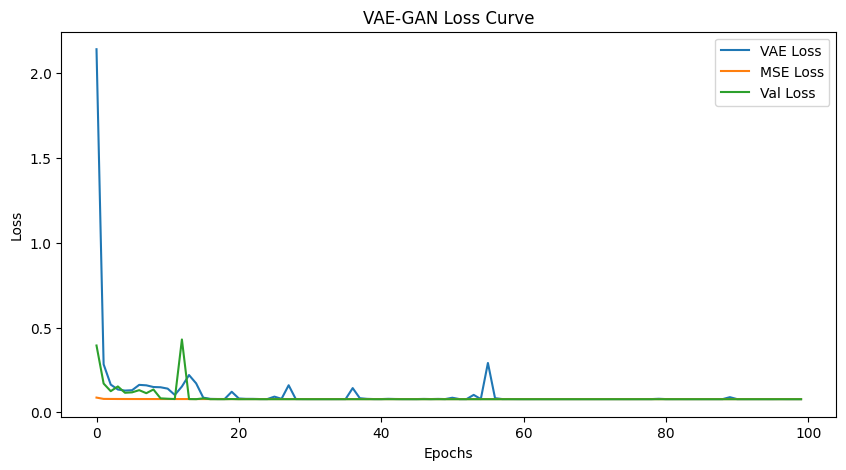

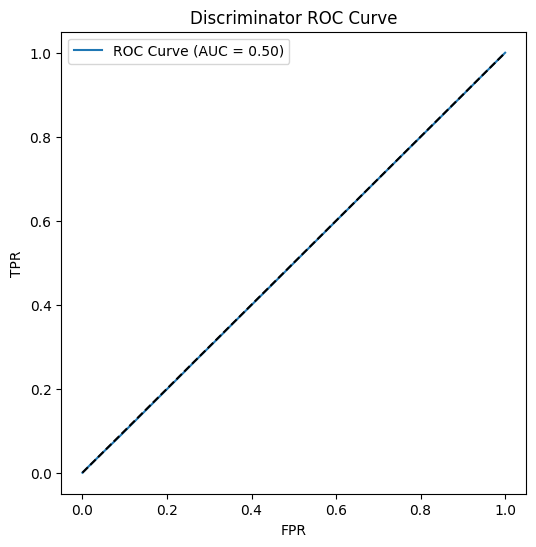

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === Updated Encoder ===
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(512 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(512 * 8 * 8, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    return mu + torch.randn_like(std) * std

# === Updated Decoder ===
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 512, 8, 8)
        return self.deconv(h)

# === Updated Discriminator ===
class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

class ImagePromptDataset(Dataset):
    def __init__(self, image_folders):
        self.image_paths = []
        for folder in image_folders:
            self.image_paths.extend([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.png')])
        self.transform = transforms.Compose([transforms.Resize((128, 128)), transforms.ToTensor()])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)

def compute_discriminator_accuracy(discriminator, real_z, fake_z):
    with torch.no_grad():
        real_preds = discriminator(real_z)
        fake_preds = discriminator(fake_z)
        return ((real_preds > 0.5).float().mean() + (fake_preds < 0.5).float().mean()) / 2

def validate_vae_gan(val_loader, encoder, decoder, discriminator):
    encoder.eval(), decoder.eval(), discriminator.eval()
    total_loss, total_acc = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            mu, logvar = encoder(batch)
            z = reparameterize(mu, logvar)
            recon = decoder(z)
            recon_loss = F.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(batch)
            loss = recon_loss + kl_loss
            acc = compute_discriminator_accuracy(discriminator, torch.randn_like(z), z)
            total_loss += loss.item()
            total_acc += acc
    return total_loss / len(val_loader), total_acc / len(val_loader)

def train_vae_gan(train_loader, val_loader, encoder, decoder, discriminator, vae_opt, dis_opt, epochs=100):
    scheduler_vae = torch.optim.lr_scheduler.StepLR(vae_opt, step_size=30, gamma=0.5)
    scheduler_dis = torch.optim.lr_scheduler.StepLR(dis_opt, step_size=30, gamma=0.5)

    history = {
        'vae_loss': [], 'recon_loss': [], 'kl_loss': [], 'dis_loss': [],
        'mse_loss': [],  # <== ADDED
        'train_acc': [], 'val_loss': [], 'val_acc': [],
        'all_real_scores': [], 'all_fake_scores': [], 'all_labels': []
    }

    for epoch in range(epochs):
        encoder.train(), decoder.train(), discriminator.train()
        total_vae, total_rec, total_kl, total_dis, total_acc, total_mse = 0, 0, 0, 0, 0, 0

        real_scores, fake_scores, labels = [], [], []

        for batch in train_loader:
            batch = batch.to(device)
            mu, logvar = encoder(batch)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            mse_loss = F.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(batch)
            vae_loss = mse_loss + kl_loss

            real_labels = torch.ones(len(batch), 1).to(device) * 0.9
            fake_labels = torch.zeros(len(batch), 1).to(device)

            real_z = torch.randn_like(z)
            dis_opt.zero_grad()
            d_real = discriminator(real_z)
            d_fake = discriminator(z.detach())
            dis_loss = F.binary_cross_entropy(d_real, real_labels) + F.binary_cross_entropy(d_fake, fake_labels)
            dis_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=5.0)
            dis_opt.step()

            vae_opt.zero_grad()
            gan_loss = F.binary_cross_entropy(discriminator(z), real_labels)
            total_loss = vae_loss + 0.1 * gan_loss
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), max_norm=5.0)
            vae_opt.step()

            acc = compute_discriminator_accuracy(discriminator, real_z, z)
            real_scores += d_real.cpu().flatten().tolist()
            fake_scores += d_fake.cpu().flatten().tolist()
            labels += [1]*len(d_real) + [0]*len(d_fake)

            total_vae += vae_loss.item()
            total_rec += (mse_loss.item() + kl_loss.item())
            total_kl += kl_loss.item()
            total_dis += dis_loss.item()
            total_mse += mse_loss.item()
            total_acc += acc

        scheduler_vae.step()
        scheduler_dis.step()

        val_loss, val_acc = validate_vae_gan(val_loader, encoder, decoder, discriminator)

        history['vae_loss'].append(total_vae / len(train_loader))
        history['recon_loss'].append(total_rec / len(train_loader))
        history['kl_loss'].append(total_kl / len(train_loader))
        history['dis_loss'].append(total_dis / len(train_loader))
        history['mse_loss'].append(total_mse / len(train_loader))  # <== ADDED
        history['train_acc'].append(total_acc / len(train_loader))
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['all_real_scores'] += real_scores
        history['all_fake_scores'] += fake_scores
        history['all_labels'] += labels

        print(f"[{epoch+1}/{epochs}] 🔧 VAE: {total_vae:.2f} | MSE: {total_mse:.2f} | KL: {total_kl:.2f} | "
              f"D: {total_dis:.2f} | Train Acc: {total_acc/len(train_loader):.3f} | "
              f"Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.3f}")

    return history

def plot_loss_and_roc(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['vae_loss'], label="VAE Loss")
    plt.plot(history['mse_loss'], label="MSE Loss")  # <== ADDED
    plt.plot(history['val_loss'], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("VAE-GAN Loss Curve")
    plt.savefig("augmented_loss.png")
    plt.show()

    all_scores = np.array(history['all_real_scores'] + history['all_fake_scores'])
    all_labels = np.array(history['all_labels'])

    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Discriminator ROC Curve")
    plt.legend()
    plt.savefig("augmented_roc.png")
    plt.show()


train_folder = "/content/drive/MyDrive/stable_diffusion_outputs_resized/train"
aug_folder = "/content/drive/MyDrive/stable_diffusion_outputs_augmented/train"

dataset = ImagePromptDataset([train_folder, aug_folder])
train_set, val_set = train_test_split(dataset, test_size=0.1, shuffle=True)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

encoder = Encoder(128).to(device)
decoder = Decoder(128).to(device)
discriminator = Discriminator(128).to(device)

vae_opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)
dis_opt = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

history = train_vae_gan(train_loader, val_loader, encoder, decoder, discriminator, vae_opt, dis_opt, epochs=100)
plot_loss_and_roc(history)
